In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("C:\\Users\\Dhanushree\\Documents\\employee_attrition_data.csv")

print(df.shape)
df.head()

(20600, 32)


,Employee_ID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EmployeeCount,Gender,JobInvolvement,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,HireDate,Location,DailyRate,HourlyRate,MonthlyRate,EnvironmentSatisfaction
0,EMP30123,57,No,Non-Travel,Admin,1.0,High School,1,Female,4,...,2,2.0,7,1,15-05-2025,Chandigarh,709,65,36384,2.0
1,EMP93612,53,YES,Travel_Rarely,Marketing,14.0,Diploma,3,male,3,...,1,1.0,2,6,28-09-2025,Kolkata,1279,102,44448,2.0
2,EMP54979,42,NO,Travel_Frequently,IT,24.0,Bachelor's,1,M,2,...,2,NaN,7,3,13-05-2026,Jaipur,1736,103,43121,1.0
3,EMP19255,55,No,Travel_Rarely,Admin,25.0,High School,2,male,4,...,2,8.0,1,4,11-07-2027,Bangalore,1919,156,30650,4.0
4,EMP89513,30,No,Non-Travel,Admin,12.0,PhD,1,M,2,...,4,0.0,10,6,22-02-2025,Ahmedabad,912,190,20413,2.0


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (20600, 32)

Columns:
Index(['Employee_ID', 'Age', 'Attrition', 'BusinessTravel', 'Department',
       'DistanceFromHome', 'Education', 'EmployeeCount', 'Gender',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'HireDate', 'Location', 'DailyRate', 'HourlyRate', 'MonthlyRate',
       'EnvironmentSatisfaction'],
      dtype='object')

Data Types:
Employee_ID                  object
Age                           int64
Attrition                    object
BusinessTravel               object
Department                   object
DistanceFromHome            float64
Education                    object
EmployeeCount                 int64
Gender                    

In [5]:
print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (20600, 32)
After: (20600, 32)


In [6]:
df.columns = df.columns.str.strip()

df.columns = df.columns.str.replace(" ", "_")

print(df.columns)

Index(['Employee_ID', 'Age', 'Attrition', 'BusinessTravel', 'Department',
       'DistanceFromHome', 'Education', 'EmployeeCount', 'Gender',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'HireDate', 'Location', 'DailyRate', 'HourlyRate', 'MonthlyRate',
       'EnvironmentSatisfaction'],
      dtype='object')


In [7]:
for col in df.select_dtypes(include='object').columns:
    
    df[col] = df[col].astype(str).str.strip()

In [8]:
# Convert everything to string first
df['Attrition'] = df['Attrition'].astype(str).str.strip()

# Replace inconsistent values
df['Attrition'] = df['Attrition'].replace({
    'Y': 'Yes',
    '1': 'Yes',
    'YES': 'Yes',
    'yes': 'Yes',

    'N': 'No',
    '0': 'No',
    'NO': 'No',
    'no': 'No',

    'nan': np.nan
})
print(df['Attrition'].value_counts())

Attrition
Yes    10312
No     10213
Name: count, dtype: int64


In [9]:
# Replace all gender variations

df['Gender'] = df['Gender'].replace({

    'F':'Female',
    'FEMALE':'Female',
    'female':'Female',

    'M':'Male',
    'MALE':'Male',
    'male':'Male'

})

# Convert string 'nan' into actual NaN

df['Gender'] = df['Gender'].replace('nan', np.nan)

# Fill missing values with mode

df['Gender'].fillna(
    df['Gender'].mode()[0],
    inplace=True
)
print(df['Gender'].value_counts())

Gender
Female    10463
Male      10137
Name: count, dtype: int64


C:\Users\Dhanushree\AppData\Local\Temp\ipykernel_3492\2747203397.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(


In [15]:
df['OverTime'] = df['OverTime'].replace({
    0: 'No',
    1: 'Yes',
    '0': 'No',
    '1': 'Yes'
})

print(df['OverTime'].value_counts())

OverTime
No     10356
Yes    10244
Name: count, dtype: int64


In [16]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

In [17]:
df.replace({
    'YES':'Yes',
    'yes':'Yes',
    'NO':'No',
    'no':'No',
    'Male':'Male',
    'male':'Male',
    'Female':'Female',
    'female':'Female'
}, inplace=True)

In [18]:
df['HireDate'] = pd.to_datetime(
    
    df['HireDate'],
    
    errors='coerce'
)

In [19]:
df['HireDate'].head()

0   2025-05-15
1   2025-09-28
2   2026-05-13
3   2027-07-11
4   2025-02-22
Name: HireDate, dtype: datetime64[ns]

In [20]:
today = pd.Timestamp.today()

df['Tenure_Years'] = (
    
    today - df['HireDate']
    
).dt.days / 365

In [21]:
num_cols = df.select_dtypes(
    
    include=['int64','float64']
    
).columns

In [22]:
for col in num_cols:
    
    df[col].fillna(
        
        df[col].median(),
        
        inplace=True
    )

C:\Users\Dhanushree\AppData\Local\Temp\ipykernel_3492\3649463540.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


In [23]:
cat_cols = df.select_dtypes(
    
    include='object'
    
).columns

In [24]:
for col in cat_cols:
    
    df[col].fillna(
        
        df[col].mode()[0],
        
        inplace=True
    )

C:\Users\Dhanushree\AppData\Local\Temp\ipykernel_3492\3007849411.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


In [25]:
df['HireDate'].head(10)

0   2025-05-15
1   2025-09-28
2   2026-05-13
3   2027-07-11
4   2025-02-22
5   2026-01-09
6   2024-03-20
7   2026-03-14
8   2027-01-19
9   2024-06-18
Name: HireDate, dtype: datetime64[ns]

In [26]:
df['HireDate'].sample(10)

18801   2027-12-11
8587    2027-02-17
19607   2025-02-19
1531    2024-11-08
19180   2025-09-16
14333   2025-03-05
2450    2026-10-27
11043   2024-11-07
5444    2027-03-29
11793   2027-09-11
Name: HireDate, dtype: datetime64[ns]

In [27]:
df['HireDate'] = pd.to_datetime(
    df['HireDate'],
    errors='coerce'
)

In [28]:
median_date = df['HireDate'].dropna().median()

df['HireDate'].fillna(
    median_date,
    inplace=True
)

C:\Users\Dhanushree\AppData\Local\Temp\ipykernel_3492\3244570569.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['HireDate'].fillna(


In [29]:
df.isnull().sum()

Employee_ID                 0
Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EmployeeCount               0
Gender                      0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
HireDate                    0
Location                    0
DailyRate                   0
HourlyRate                  0
MonthlyRate                 0
EnvironmentSatisfaction     0
Tenure_Years                0
dtype: int

In [30]:
print(df.duplicated().sum())

0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20600 entries, 0 to 20599
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Employee_ID               20600 non-null  object        
 1   Age                       20600 non-null  int64         
 2   Attrition                 20600 non-null  object        
 3   BusinessTravel            20600 non-null  object        
 4   Department                20600 non-null  object        
 5   DistanceFromHome          20600 non-null  float64       
 6   Education                 20600 non-null  object        
 7   EmployeeCount             20600 non-null  int64         
 8   Gender                    20600 non-null  object        
 9   JobInvolvement            20600 non-null  int64         
 10  JobLevel                  20600 non-null  int64         
 11  JobRole                   20600 non-null  object        
 12  JobSatisfaction   

In [32]:
print(df['Attrition'].unique())

['No' 'Yes' 'nan']


In [33]:
df['Attrition'] = df['Attrition'].replace('nan', np.nan)

In [34]:
df = df.dropna(subset=['Attrition'])

In [35]:
print(df['Attrition'].value_counts())
print(df.shape)

Attrition
Yes    10312
No     10213
Name: count, dtype: int64
(20525, 33)


In [36]:
df['Attrition'].value_counts(normalize=True)*100

Attrition
Yes    50.241169
No     49.758831
Name: proportion, dtype: float64

In [37]:
print(df['Attrition'].isnull().sum())

0


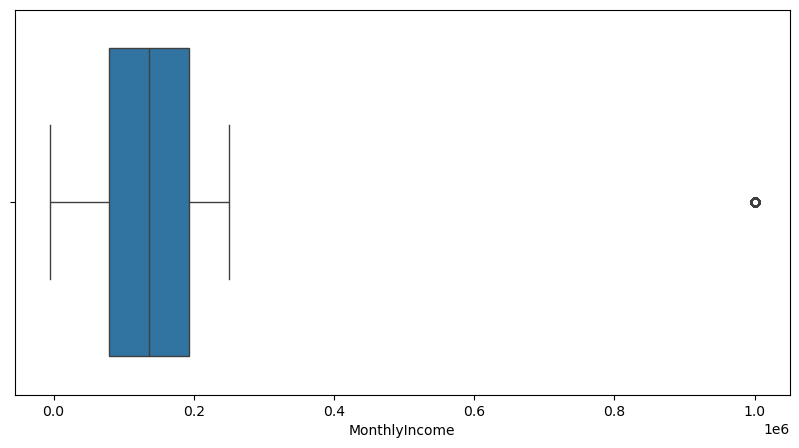

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(
    
    x=df['MonthlyIncome']
    
)

plt.show()

In [39]:
Q1 = df['MonthlyIncome'].quantile(0.25)

Q3 = df['MonthlyIncome'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df['MonthlyIncome'] = np.where(
    
    df['MonthlyIncome'] > upper,
    
    upper,
    
    df['MonthlyIncome']
)

df['MonthlyIncome'] = np.where(
    
    df['MonthlyIncome'] < lower,
    
    lower,
    
    df['MonthlyIncome']
)

In [40]:
# Remove Employee_ID
df.drop('Employee_ID', axis=1, inplace=True)

# Remove HireDate
df.drop('HireDate', axis=1, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

In [41]:
df.to_csv(
    
    "employee_attrition_cleaned.csv",
    
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [42]:
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EmployeeCount,Gender,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,Location,DailyRate,HourlyRate,MonthlyRate,EnvironmentSatisfaction,Tenure_Years
0,57,No,Non-Travel,Admin,1.0,High School,1,Female,4,3,...,2,2.0,7,1,Chandigarh,709,65,36384,2.0,1.079452
1,53,Yes,Travel_Rarely,Marketing,14.0,Diploma,3,Male,3,5,...,1,1.0,2,6,Kolkata,1279,102,44448,2.0,0.706849
2,42,No,Travel_Frequently,IT,24.0,Bachelor's,1,Male,2,3,...,2,4.0,7,3,Jaipur,1736,103,43121,1.0,0.084932
3,55,No,Travel_Rarely,Admin,25.0,High School,2,Male,4,2,...,2,8.0,1,4,Bangalore,1919,156,30650,4.0,-1.076712
4,30,No,Non-Travel,Admin,12.0,PhD,1,Male,2,2,...,4,0.0,10,6,Ahmedabad,912,190,20413,2.0,1.304110


In [43]:
df.describe()

,Age,DistanceFromHome,EmployeeCount,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,DailyRate,HourlyRate,MonthlyRate,EnvironmentSatisfaction,Tenure_Years
count,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,...,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000,20017.000000
mean,41.071189,17.292202,3.008493,2.500525,2.994055,2.495879,137148.398611,5.001099,17.502893,2.561922,...,3.002048,2.493730,5.399860,5.003247,5.007843,1248.715941,125.047610,29907.442474,2.488185,0.388672
std,11.255382,32.910275,1.406146,1.122277,1.415949,1.177194,68322.120522,3.170892,4.336947,1.259447,...,1.998012,1.113589,5.779961,3.176062,3.156140,432.278707,43.825621,11528.226934,1.141985,1.185528
min,22.000000,-10.000000,1.000000,1.000000,1.000000,-1.000000,-5000.000000,0.000000,10.000000,0.000000,...,0.000000,1.000000,-1.000000,0.000000,0.000000,500.000000,50.000000,10006.000000,0.000000,-2.394521
25%,31.000000,8.000000,2.000000,1.000000,2.000000,1.000000,79801.000000,2.000000,13.700000,2.000000,...,1.000000,1.000000,1.000000,2.000000,2.000000,877.000000,87.000000,19882.000000,1.000000,-0.643836
50%,41.000000,15.000000,3.000000,3.000000,3.000000,3.000000,136783.000000,5.000000,17.500000,3.000000,...,3.000000,2.000000,4.000000,5.000000,5.000000,1246.000000,125.000000,29956.000000,2.000000,0.405479
75%,51.000000,23.000000,4.000000,4.000000,4.000000,4.000000,193134.000000,8.000000,21.300000,4.000000,...,5.000000,3.000000,8.000000,8.000000,8.000000,1622.000000,163.000000,39872.000000,3.000000,1.402740
max,60.000000,500.000000,5.000000,4.000000,5.000000,5.000000,363249.500000,10.000000,25.000000,10.000000,...,6.000000,4.000000,50.000000,10.000000,10.000000,2000.000000,200.000000,49999.000000,5.000000,2.449315


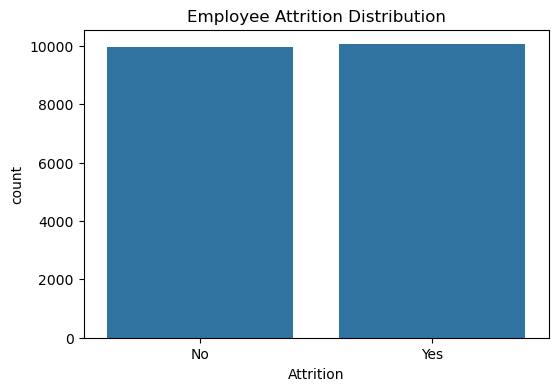

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x='Attrition',
    data=df
)

plt.title("Employee Attrition Distribution")
plt.show()

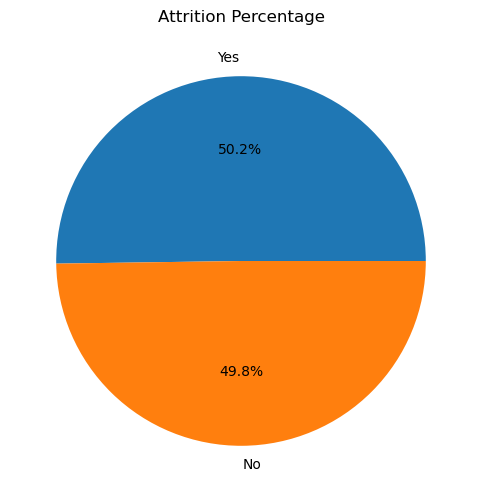

In [45]:
attrition = df['Attrition'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    attrition,
    labels=attrition.index,
    autopct='%1.1f%%'
)

plt.title("Attrition Percentage")
plt.show()

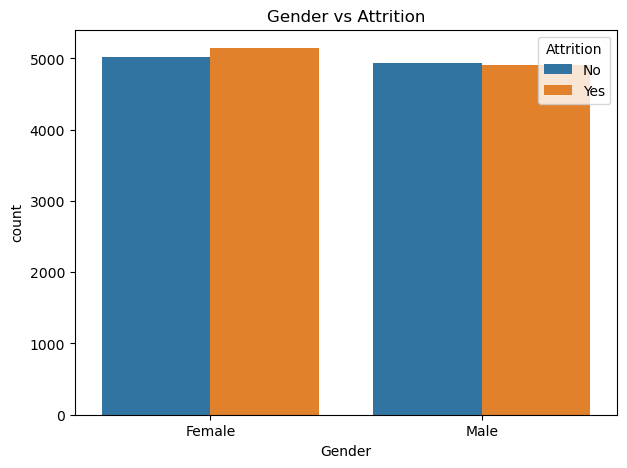

In [46]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Gender',
    hue='Attrition',
    data=df
)

plt.title("Gender vs Attrition")
plt.show()

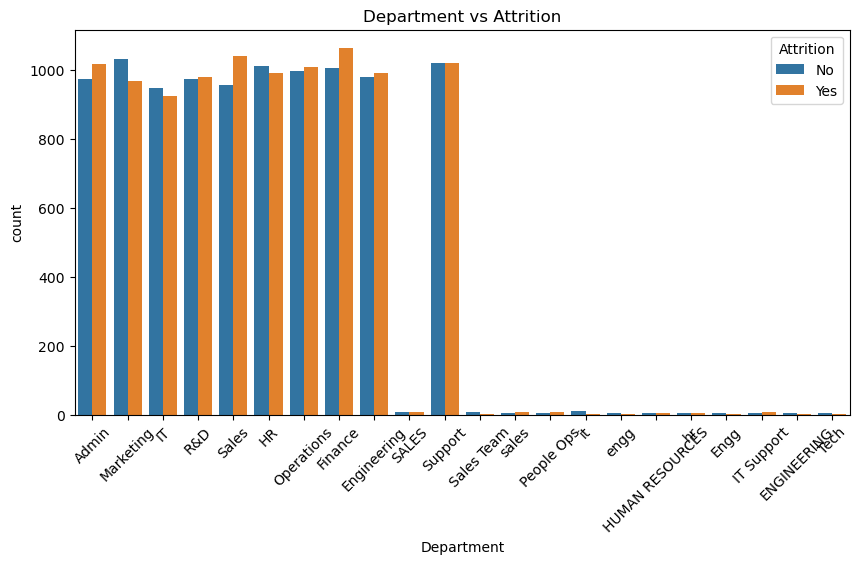

In [47]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Department',
    hue='Attrition',
    data=df
)

plt.xticks(rotation=45)

plt.title("Department vs Attrition")

plt.show()

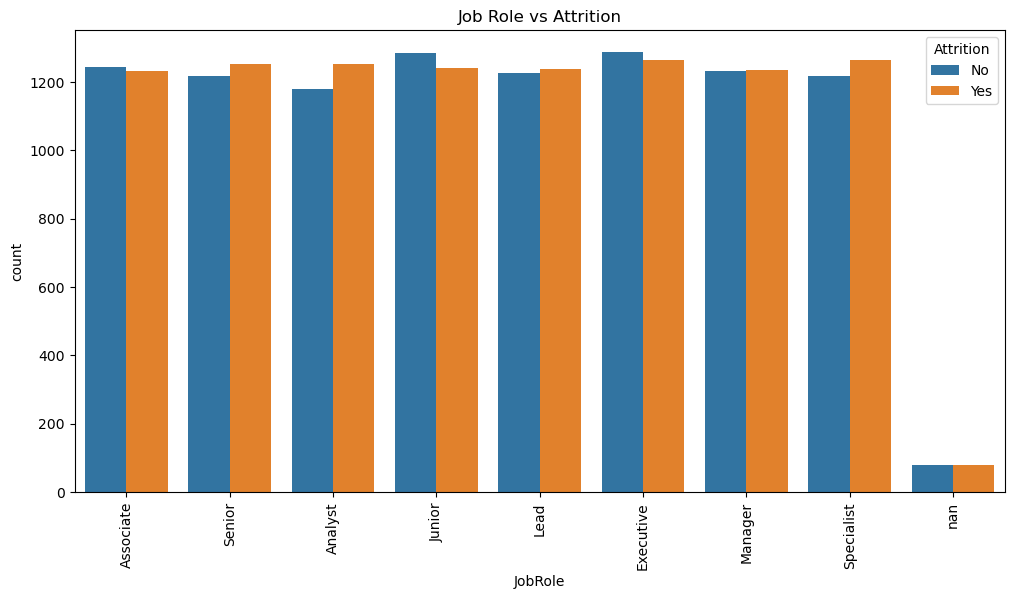

In [48]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='JobRole',
    hue='Attrition',
    data=df
)

plt.xticks(rotation=90)

plt.title("Job Role vs Attrition")

plt.show()

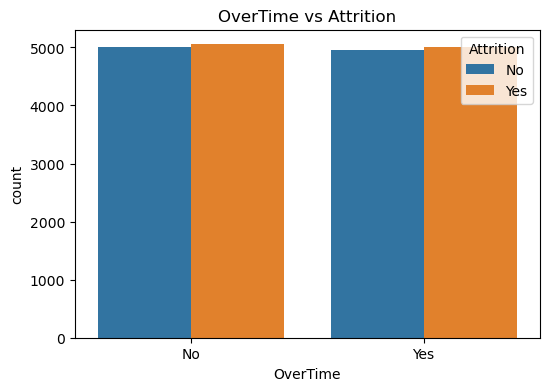

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df
)

plt.title("OverTime vs Attrition")

plt.show()

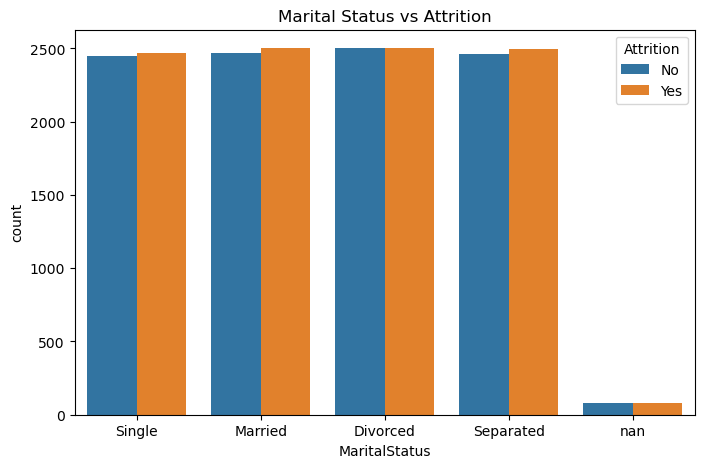

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='MaritalStatus',
    hue='Attrition',
    data=df
)

plt.title("Marital Status vs Attrition")

plt.show()

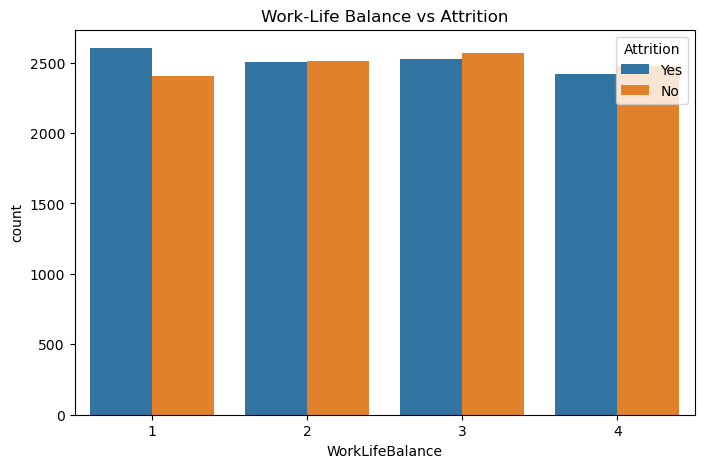

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df
)

plt.title("Work-Life Balance vs Attrition")

plt.show()

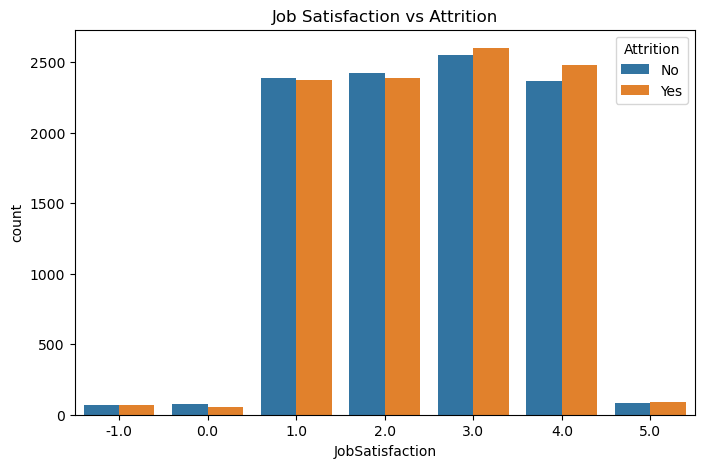

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    data=df
)

plt.title("Job Satisfaction vs Attrition")

plt.show()

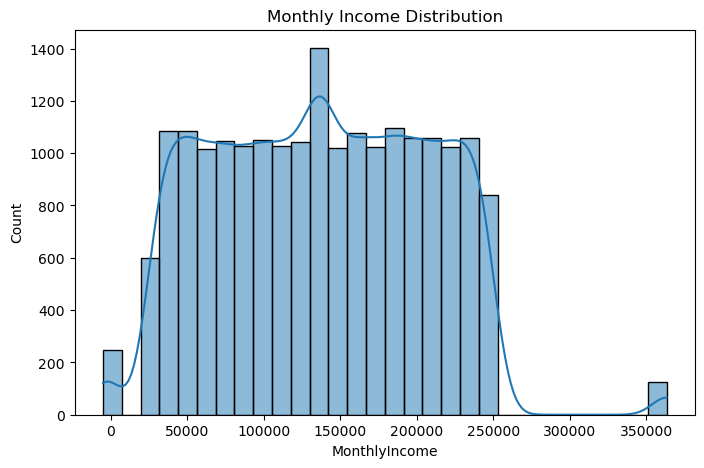

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['MonthlyIncome'],
    bins=30,
    kde=True
)

plt.title("Monthly Income Distribution")

plt.show()

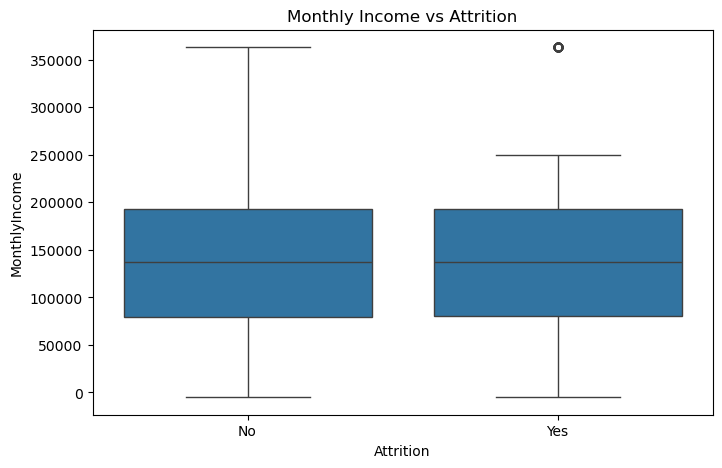

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.show()

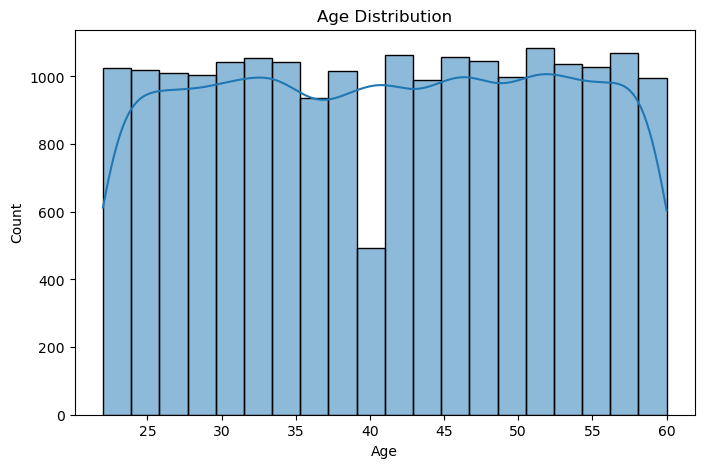

In [55]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

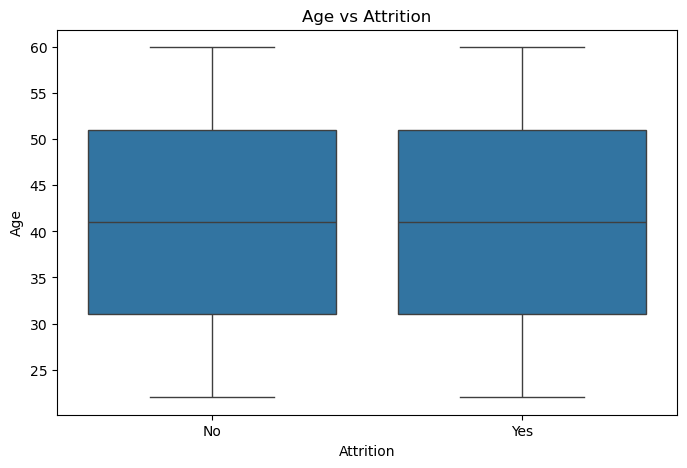

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='Age',
    data=df
)

plt.title("Age vs Attrition")

plt.show()

In [57]:
from sklearn.preprocessing import LabelEncoder

temp_df = df.copy()

le = LabelEncoder()

for col in temp_df.select_dtypes(include='object').columns:
    temp_df[col] = le.fit_transform(temp_df[col])

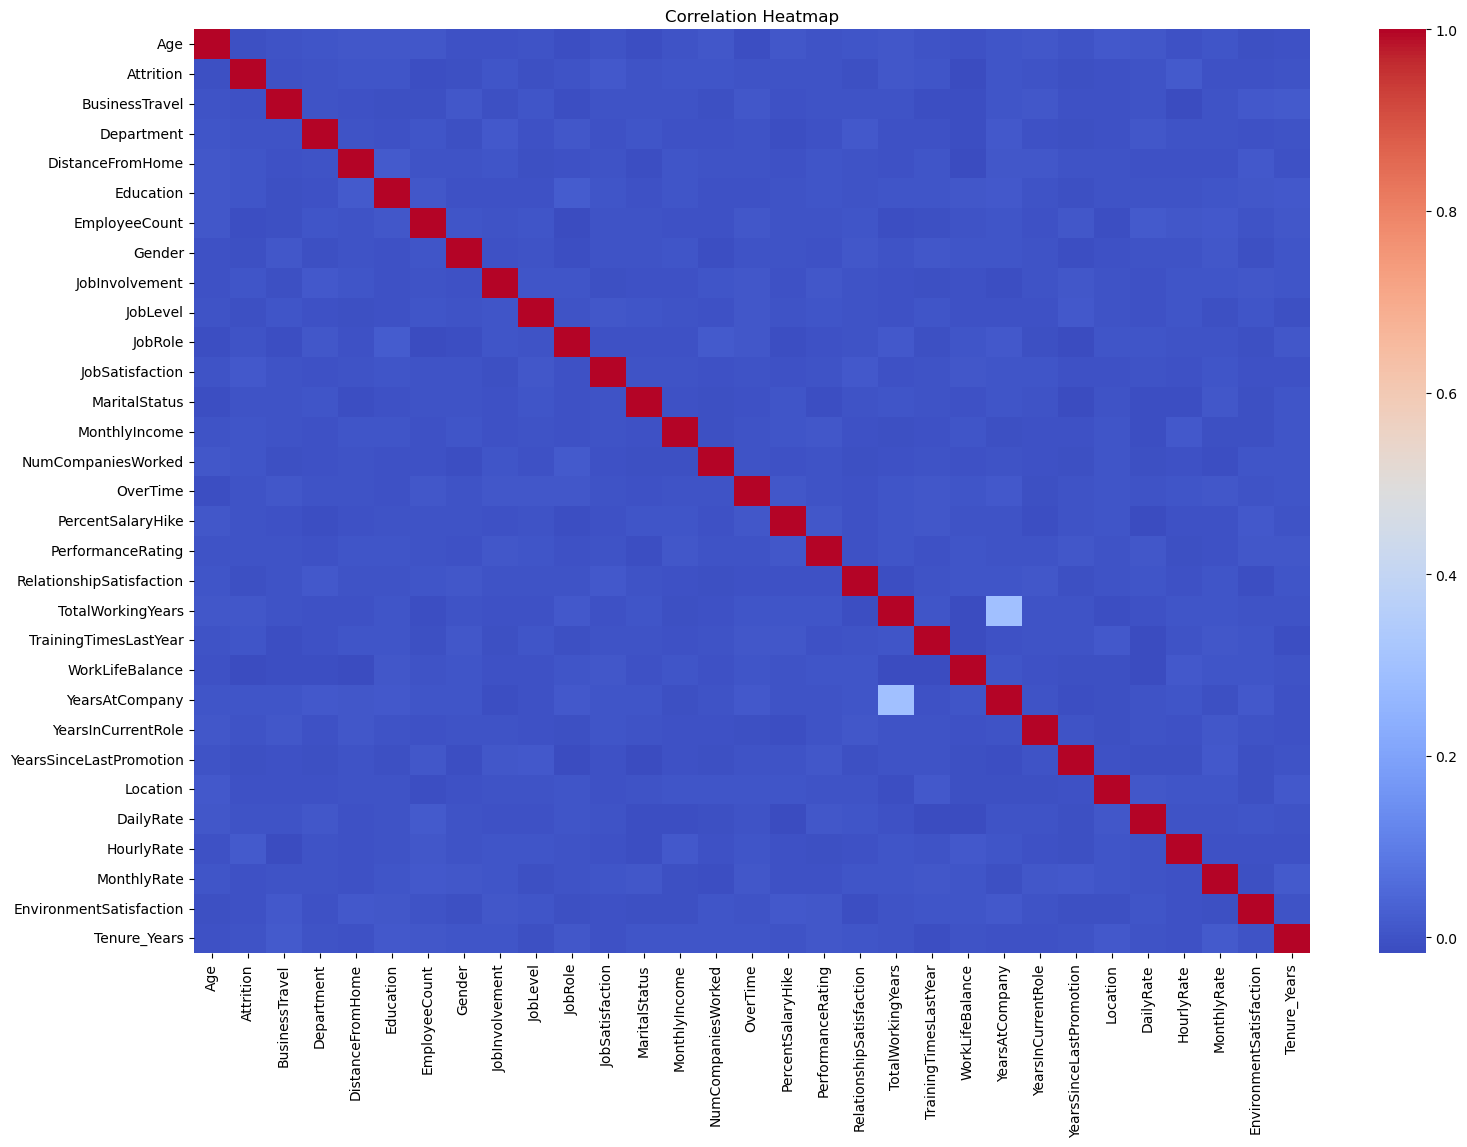

In [58]:
plt.figure(figsize=(18,12))

sns.heatmap(
    temp_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20017 entries, 0 to 20016
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       20017 non-null  int64  
 1   Attrition                 20017 non-null  object 
 2   BusinessTravel            20017 non-null  object 
 3   Department                20017 non-null  object 
 4   DistanceFromHome          20017 non-null  float64
 5   Education                 20017 non-null  object 
 6   EmployeeCount             20017 non-null  int64  
 7   Gender                    20017 non-null  object 
 8   JobInvolvement            20017 non-null  int64  
 9   JobLevel                  20017 non-null  int64  
 10  JobRole                   20017 non-null  object 
 11  JobSatisfaction           20017 non-null  float64
 12  MaritalStatus             20017 non-null  object 
 13  MonthlyIncome             20017 non-null  float64
 14  NumCom

In [60]:
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EmployeeCount,Gender,JobInvolvement,JobLevel,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,Location,DailyRate,HourlyRate,MonthlyRate,EnvironmentSatisfaction,Tenure_Years
0,57,No,Non-Travel,Admin,1.0,High School,1,Female,4,3,...,2,2.0,7,1,Chandigarh,709,65,36384,2.0,1.079452
1,53,Yes,Travel_Rarely,Marketing,14.0,Diploma,3,Male,3,5,...,1,1.0,2,6,Kolkata,1279,102,44448,2.0,0.706849
2,42,No,Travel_Frequently,IT,24.0,Bachelor's,1,Male,2,3,...,2,4.0,7,3,Jaipur,1736,103,43121,1.0,0.084932
3,55,No,Travel_Rarely,Admin,25.0,High School,2,Male,4,2,...,2,8.0,1,4,Bangalore,1919,156,30650,4.0,-1.076712
4,30,No,Non-Travel,Admin,12.0,PhD,1,Male,2,2,...,4,0.0,10,6,Ahmedabad,912,190,20413,2.0,1.304110


In [78]:
df['EmployeeCount'].value_counts()

EmployeeCount
4    4089
3    4064
2    3989
5    3955
1    3920
Name: count, dtype: int64

In [79]:
df['Attrition'].value_counts()

Attrition
Yes    10054
No      9963
Name: count, dtype: int64

In [80]:
df[['YearsAtCompany','Tenure_Years']].head()

,YearsAtCompany,Tenure_Years
0,2.0,2.0
1,1.0,1.0
2,4.0,4.0
3,8.0,8.0
4,0.0,0.0


In [84]:
df['Tenure_Years'] = df['YearsAtCompany'].copy()

In [85]:
print(df['Tenure_Years'].min())
print(df['YearsAtCompany'].min())

0.0
0.0


In [86]:
df['YearsAtCompany'] = abs(df['YearsAtCompany'])
df['Tenure_Years'] = df['YearsAtCompany']

In [87]:
(df['YearsAtCompany'] < 0).sum()
(df['Tenure_Years'] < 0).sum()

np.int64(0)

In [88]:
df_ml = df.copy()

In [89]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df_ml.select_dtypes(include='object').columns

print("Categorical Columns:")
print(cat_cols)

for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print("Encoding Completed")

Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'Education', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime', 'Location'],
      dtype='object')
Encoding Completed


In [90]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20017 entries, 0 to 20016
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       20017 non-null  int64  
 1   Attrition                 20017 non-null  int64  
 2   BusinessTravel            20017 non-null  int64  
 3   Department                20017 non-null  int64  
 4   DistanceFromHome          20017 non-null  float64
 5   Education                 20017 non-null  int64  
 6   EmployeeCount             20017 non-null  int64  
 7   Gender                    20017 non-null  int64  
 8   JobInvolvement            20017 non-null  int64  
 9   JobLevel                  20017 non-null  int64  
 10  JobRole                   20017 non-null  int64  
 11  JobSatisfaction           20017 non-null  float64
 12  MaritalStatus             20017 non-null  int64  
 13  MonthlyIncome             20017 non-null  float64
 14  NumCom

In [93]:
corr['Attrition'].sort_values(
    ascending=False
).head(15)

Attrition                1.000000
HourlyRate               0.014469
JobSatisfaction          0.013872
TotalWorkingYears        0.008054
JobInvolvement           0.005318
Tenure_Years             0.004456
YearsAtCompany           0.004456
NumCompaniesWorked       0.004347
MonthlyIncome            0.004296
TrainingTimesLastYear    0.004271
Education                0.002930
DistanceFromHome         0.002885
MaritalStatus            0.001684
JobRole                  0.001607
YearsInCurrentRole       0.001490
Name: Attrition, dtype: float64

In [94]:
from sklearn.model_selection import train_test_split

X = df_ml.drop('Attrition', axis=1)

y = df_ml['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (16013, 30)
Testing Shape: (4004, 30)


In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [96]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [97]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_lr
))

Accuracy: 0.49325674325674324

Classification Report:

              precision    recall  f1-score   support

           0       0.49      0.46      0.47      1993
           1       0.50      0.53      0.51      2011

    accuracy                           0.49      4004
   macro avg       0.49      0.49      0.49      4004
weighted avg       0.49      0.49      0.49      4004



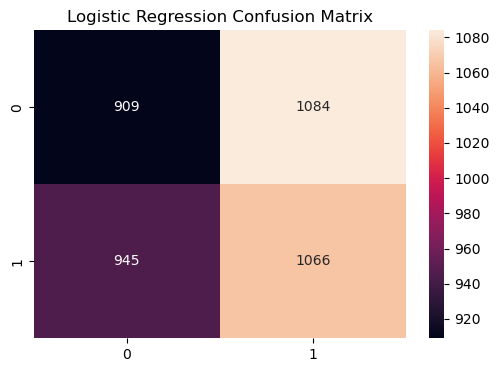

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [99]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(
    y_test,
    lr.predict_proba(X_test_scaled)[:,1]
)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.49494339087851735


In [100]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.5062437562437563

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.57      0.54      1993
           1       0.51      0.44      0.47      2011

    accuracy                           0.51      4004
   macro avg       0.51      0.51      0.50      4004
weighted avg       0.51      0.51      0.50      4004



In [101]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.5117382617382618

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.53      0.52      1993
           1       0.51      0.50      0.51      2011

    accuracy                           0.51      4004
   macro avg       0.51      0.51      0.51      4004
weighted avg       0.51      0.51      0.51      4004



In [102]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                    Feature  Importance
25                DailyRate    0.063354
27              MonthlyRate    0.062928
12            MonthlyIncome    0.062607
26               HourlyRate    0.058339
15        PercentSalaryHike    0.057341
0                       Age    0.050498
3          DistanceFromHome    0.047865
18        TotalWorkingYears    0.044741
23  YearsSinceLastPromotion    0.036495
22       YearsInCurrentRole    0.035848


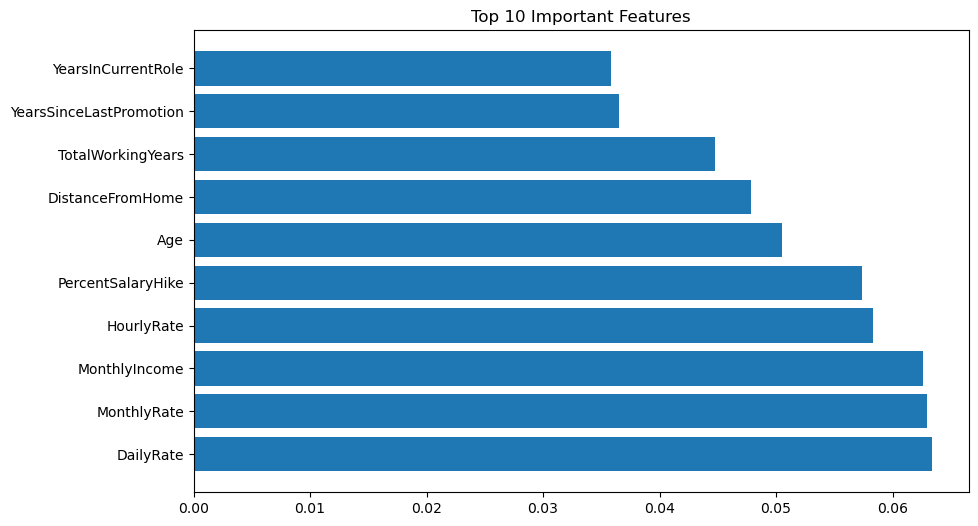

In [103]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title("Top 10 Important Features")
plt.show()

In [106]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.6 MB/s eta 0:01:02
   ---------------------------------------- 0.8/101.7 MB 1.8 MB/s eta 0:00:57
    --------------------------------------- 1.3/101.7 MB 1.9 MB/s eta 0:00:55
    --------------------------------------- 1.8/101.7 MB 2.0 MB/s eta 0:00:50
    --------------------------------------- 2.4/101.7 MB 2.2 MB/s eta 0:00:46
   - -------------------------------------- 2.9/101.7 MB 2.2 MB/s eta 0:00:45
   - -------------------------------------- 3.4/101.7 MB 2.3 MB/s eta 0:00:44
   - -------------------------------------- 4.2/101.7 MB 2.5 MB/s eta 0:00:40
   - -------------------------------------- 5.0/101.7 MB 2.6 MB/s eta 0:00:38
   -- ------------------------------------- 5.5/101.7 MB 2.6 MB/s eta 0:00:38
   -- ------------------------------------- 5.8/101.7 MB 2.5 MB/s eta 0:00:40


In [107]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print(classification_report(
    y_test,
    y_pred_xgb
))

Accuracy: 0.4865134865134865
              precision    recall  f1-score   support

           0       0.48      0.47      0.48      1993
           1       0.49      0.50      0.49      2011

    accuracy                           0.49      4004
   macro avg       0.49      0.49      0.49      4004
weighted avg       0.49      0.49      0.49      4004



In [108]:
import joblib

joblib.dump(rf, "employee_attrition_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [109]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [113]:
import os

print(os.getcwd())

C:\Users\Dhanushree


In [114]:
import os

folders = [
    "Employee_Attrition_Project/dataset",
    "Employee_Attrition_Project/notebooks",
    "Employee_Attrition_Project/models",
    "Employee_Attrition_Project/app",
    "Employee_Attrition_Project/report/images",
    "Employee_Attrition_Project/ppt"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [115]:
df.to_csv(
    "Employee_Attrition_Project/dataset/employee_attrition_cleaned.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


In [116]:
import joblib

joblib.dump(
    rf,
    "Employee_Attrition_Project/models/employee_attrition_model.pkl"
)

print("Model Saved")

Model Saved


In [117]:
joblib.dump(
    scaler,
    "Employee_Attrition_Project/models/scaler.pkl"
)

print("Scaler Saved")

Scaler Saved


In [118]:
plt.savefig(
    "Employee_Attrition_Project/report/images/feature_importance.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [ ]:
joblib.dump(
    scaler,
    "Employee_Attrition_Project/notebooks"
)

print("Scaler Saved")

In [1]:
import os

for root, dirs, files in os.walk("Employee_Attrition_Project"):
    for file in files:
        print(os.path.join(root, file))

Employee_Attrition_Project\dataset\employee_attrition_cleaned.csv
Employee_Attrition_Project\models\employee_attrition_model.pkl
Employee_Attrition_Project\models\scaler.pkl
Employee_Attrition_Project\report\images\feature_importance.png


In [2]:
import os
print(os.getcwd())

C:\Users\Dhanushree
